In [1]:
import sys
!{sys.executable} -m pip install nltk spacy matplotlib pandas --quiet
!{sys.executable} -m spacy download en_core_web_sm --quiet

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')

import spacy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk import pos_tag

nlp = spacy.load("en_core_web_sm")
print("All libraries loaded successfully!")


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\Manasi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\Manasi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Manasi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Manasi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Manasi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Manasi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Manasi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


All libraries loaded successfully!


In [2]:
news_article = """
Artificial intelligence is rapidly transforming the global technology landscape.
Major companies like Google, Microsoft, and OpenAI are aggressively investing billions
of dollars into developing powerful large language models and generative AI systems.
These advanced systems can now write code, compose music, generate realistic images,
and even assist doctors in diagnosing complex medical conditions.

Governments around the world are urgently scrambling to regulate artificial intelligence
technologies before they become too powerful to control. The European Union recently
passed the landmark AI Act, which imposes strict rules on high-risk AI applications
in sectors like healthcare, finance, and law enforcement.

Researchers at leading universities warn that without proper ethical guidelines,
AI systems could unintentionally amplify existing social biases and inequalities.
Meanwhile, thousands of tech workers and scientists have signed open letters demanding
responsible development and transparent deployment of these revolutionary technologies.
"""

print("News Article:")
print("-" * 60)
print(news_article)
print(f"\nTotal characters: {len(news_article)}")

News Article:
------------------------------------------------------------

Artificial intelligence is rapidly transforming the global technology landscape.
Major companies like Google, Microsoft, and OpenAI are aggressively investing billions
of dollars into developing powerful large language models and generative AI systems.
These advanced systems can now write code, compose music, generate realistic images,
and even assist doctors in diagnosing complex medical conditions.

Governments around the world are urgently scrambling to regulate artificial intelligence
technologies before they become too powerful to control. The European Union recently
passed the landmark AI Act, which imposes strict rules on high-risk AI applications
in sectors like healthcare, finance, and law enforcement.

Researchers at leading universities warn that without proper ethical guidelines,
AI systems could unintentionally amplify existing social biases and inequalities.
Meanwhile, thousands of tech workers an

In [3]:
print("=" * 60)
print("POS TAGGING — NLTK")
print("=" * 60)

# Tokenize and tag
tokens = word_tokenize(news_article)
nltk_tagged = pos_tag(tokens)

# NLTK POS tag descriptions
tag_descriptions = {
    'NN':'Noun (singular)', 'NNS':'Noun (plural)', 'NNP':'Proper Noun (singular)',
    'NNPS':'Proper Noun (plural)', 'VB':'Verb (base)', 'VBD':'Verb (past tense)',
    'VBG':'Verb (gerund)', 'VBN':'Verb (past participle)', 'VBP':'Verb (non-3rd person)',
    'VBZ':'Verb (3rd person)', 'JJ':'Adjective', 'JJR':'Adjective (comparative)',
    'JJS':'Adjective (superlative)', 'RB':'Adverb', 'RBR':'Adverb (comparative)',
    'RBS':'Adverb (superlative)', 'PRP':'Personal Pronoun', 'PRP$':'Possessive Pronoun',
    'DT':'Determiner', 'IN':'Preposition', 'CC':'Coordinating Conjunction',
    'CD':'Cardinal Number', 'TO':'to', 'MD':'Modal', 'WP':'Wh-pronoun',
    'WDT':'Wh-determiner', 'WRB':'Wh-adverb', 'EX':'Existential there',
    'FW':'Foreign Word', 'LS':'List item marker', 'PDT':'Predeterminer',
    'POS':'Possessive ending', 'RP':'Particle', 'SYM':'Symbol',
    'UH':'Interjection', ',':'Comma', '.':'Period', ':':'Colon/Semicolon',
    "''":"Quote", '``':'Open Quote', '-LRB-':'Left Bracket', '-RRB-':'Right Bracket',
    '$':'Dollar', '#':'Pound'
}

print(f"\n{'Token':<25} {'POS Tag':<12} {'Description'}")
print("-" * 65)
for token, tag in nltk_tagged[:40]:   # show first 40
    desc = tag_descriptions.get(tag, 'Other')
    print(f"{token:<25} {tag:<12} {desc}")

print(f"\n... (showing 40 of {len(nltk_tagged)} tokens)")

POS TAGGING — NLTK

Token                     POS Tag      Description
-----------------------------------------------------------------
Artificial                JJ           Adjective
intelligence              NN           Noun (singular)
is                        VBZ          Verb (3rd person)
rapidly                   RB           Adverb
transforming              VBG          Verb (gerund)
the                       DT           Determiner
global                    JJ           Adjective
technology                NN           Noun (singular)
landscape                 NN           Noun (singular)
.                         .            Period
Major                     JJ           Adjective
companies                 NNS          Noun (plural)
like                      IN           Preposition
Google                    NNP          Proper Noun (singular)
,                         ,            Comma
Microsoft                 NNP          Proper Noun (singular)
,                         

In [4]:
print("=" * 60)
print("POS TAGGING — SpaCy")
print("=" * 60)

doc = nlp(news_article)

print(f"\n{'Token':<25} {'POS (simple)':<15} {'POS (detailed)':<15} {'Dependency'}")
print("-" * 70)
for token in doc:
    if not token.is_space:
        print(f"{token.text:<25} {token.pos_:<15} {token.tag_:<15} {token.dep_}")

POS TAGGING — SpaCy

Token                     POS (simple)    POS (detailed)  Dependency
----------------------------------------------------------------------
Artificial                ADJ             JJ              amod
intelligence              NOUN            NN              nsubj
is                        AUX             VBZ             aux
rapidly                   ADV             RB              advmod
transforming              VERB            VBG             ROOT
the                       DET             DT              det
global                    ADJ             JJ              amod
technology                NOUN            NN              compound
landscape                 NOUN            NN              dobj
.                         PUNCT           .               punct
Major                     ADJ             JJ              amod
companies                 NOUN            NNS             nsubj
like                      ADP             IN              prep
Google       

In [5]:
print("=" * 60)
print("POS FREQUENCY DISTRIBUTION — NLTK")
print("=" * 60)

# Count all tags
nltk_tag_counts = Counter(tag for _, tag in nltk_tagged)

# Group into broad categories
def broad_category(tag):
    if tag.startswith('NN'):   return 'Noun'
    if tag.startswith('VB'):   return 'Verb'
    if tag.startswith('JJ'):   return 'Adjective'
    if tag.startswith('RB'):   return 'Adverb'
    if tag.startswith('PRP'):  return 'Pronoun'
    if tag in ('IN', 'TO'):    return 'Preposition'
    if tag in ('DT', 'PDT'):   return 'Determiner'
    if tag == 'CC':            return 'Conjunction'
    if tag == 'CD':            return 'Number'
    if tag == 'MD':            return 'Modal'
    if tag.startswith('NNP'):  return 'Proper Noun'
    return 'Other'

nltk_broad = Counter()
for _, tag in nltk_tagged:
    nltk_broad[broad_category(tag)] += 1

print(f"\n{'POS Category':<20} {'Count':<10} {'Percentage'}")
print("-" * 45)
total = sum(nltk_broad.values())
for cat, count in nltk_broad.most_common():
    pct = (count / total) * 100
    print(f"{cat:<20} {count:<10} {pct:.1f}%")

POS FREQUENCY DISTRIBUTION — NLTK

POS Category         Count      Percentage
---------------------------------------------
Noun                 50         32.3%
Adjective            24         15.5%
Verb                 22         14.2%
Other                18         11.6%
Preposition          16         10.3%
Adverb               9          5.8%
Conjunction          7          4.5%
Determiner           6          3.9%
Modal                2          1.3%
Pronoun              1          0.6%


In [6]:
print("=" * 60)
print("POS FREQUENCY DISTRIBUTION — SpaCy")
print("=" * 60)

spacy_pos_counts = Counter(
    token.pos_ for token in doc if not token.is_space and not token.is_punct
)

print(f"\n{'POS Category':<20} {'Count':<10} {'Percentage'}")
print("-" * 45)
total_spacy = sum(spacy_pos_counts.values())
for pos, count in spacy_pos_counts.most_common():
    pct = (count / total_spacy) * 100
    print(f"{pos:<20} {count:<10} {pct:.1f}%")

POS FREQUENCY DISTRIBUTION — SpaCy

POS Category         Count      Percentage
---------------------------------------------
NOUN                 41         29.5%
ADJ                  21         15.1%
VERB                 20         14.4%
ADP                  12         8.6%
PROPN                11         7.9%
ADV                  9          6.5%
CCONJ                7          5.0%
AUX                  6          4.3%
DET                  6          4.3%
PART                 2          1.4%
SCONJ                2          1.4%
PRON                 2          1.4%


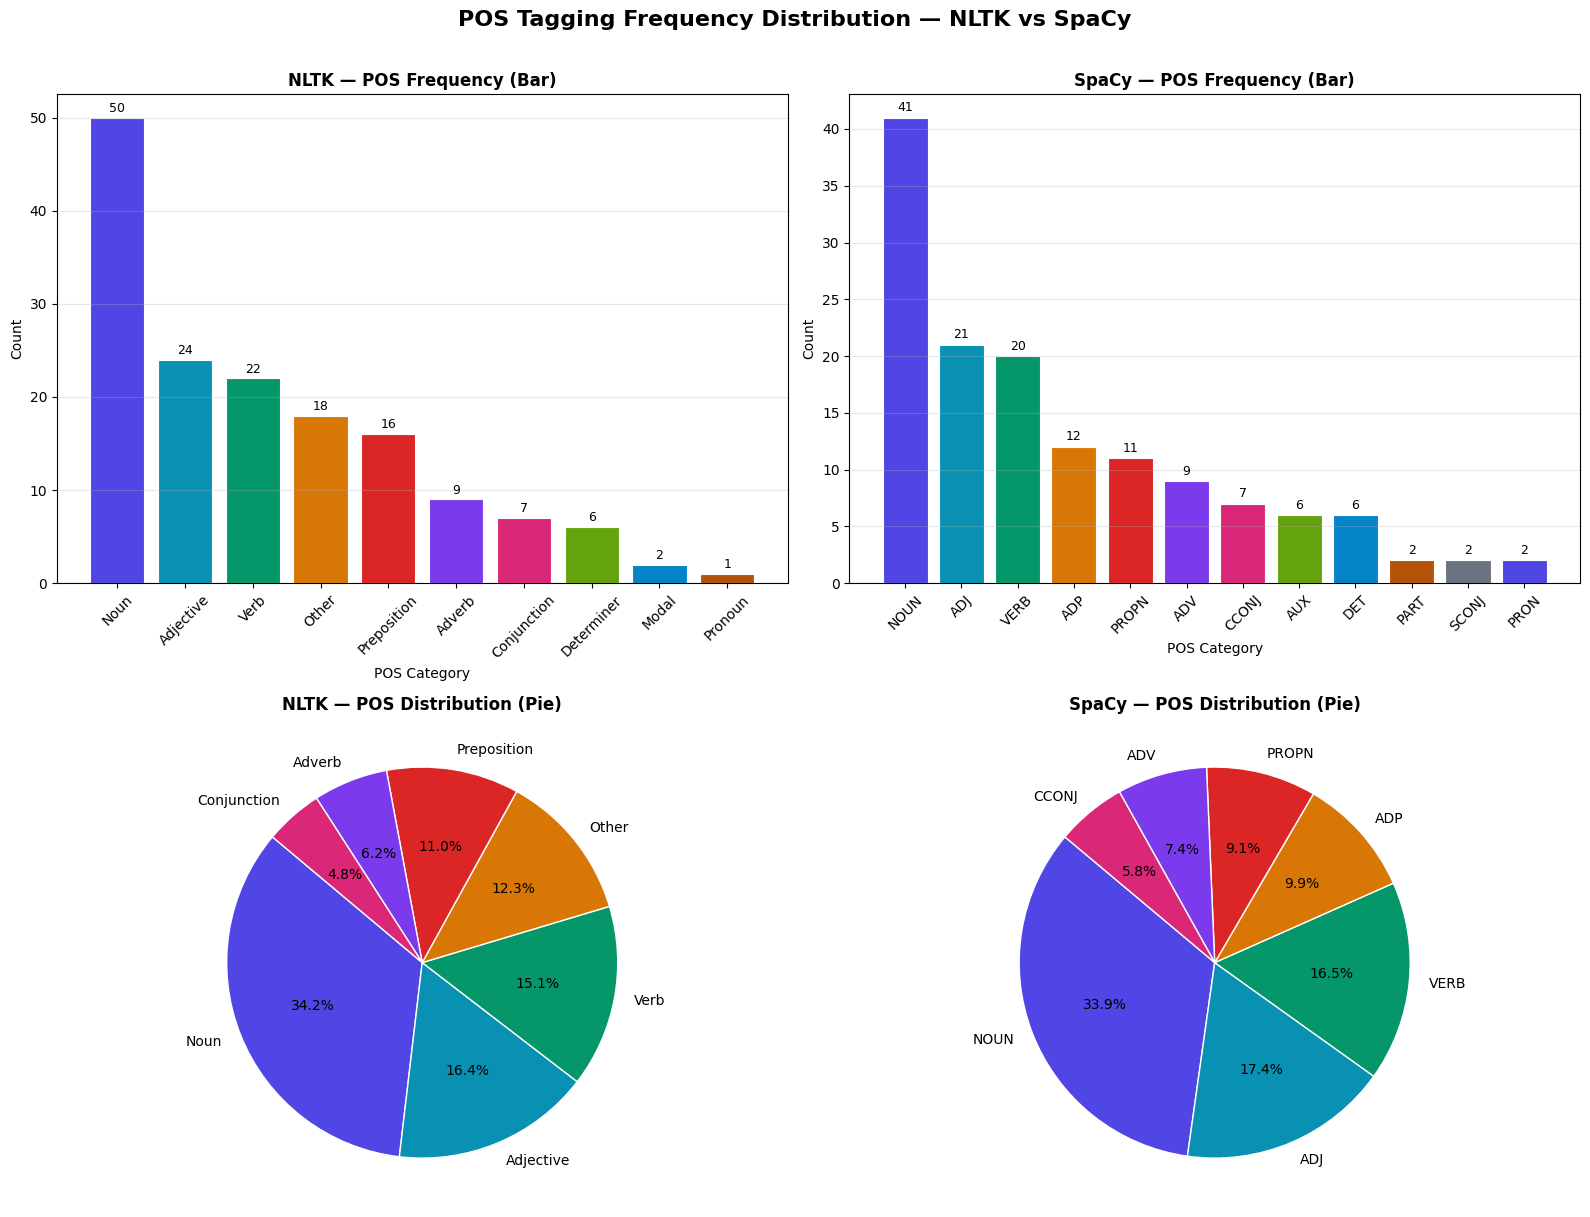

Chart saved as pos_distribution.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('POS Tagging Frequency Distribution — NLTK vs SpaCy', 
             fontsize=16, fontweight='bold', y=1.01)

colors = ['#4f46e5','#0891b2','#059669','#d97706','#dc2626',
          '#7c3aed','#db2777','#65a30d','#0284c7','#b45309','#6b7280']

# --- Plot 1: NLTK Bar Chart ---
ax1 = axes[0, 0]
categories_nltk = [k for k, _ in nltk_broad.most_common()]
counts_nltk     = [v for _, v in nltk_broad.most_common()]
bars = ax1.bar(categories_nltk, counts_nltk, color=colors[:len(categories_nltk)], edgecolor='white', linewidth=0.8)
ax1.set_title('NLTK — POS Frequency (Bar)', fontweight='bold')
ax1.set_xlabel('POS Category')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, counts_nltk):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# --- Plot 2: SpaCy Bar Chart ---
ax2 = axes[0, 1]
categories_spacy = [k for k, _ in spacy_pos_counts.most_common()]
counts_spacy     = [v for _, v in spacy_pos_counts.most_common()]
bars2 = ax2.bar(categories_spacy, counts_spacy, color=colors[:len(categories_spacy)], edgecolor='white', linewidth=0.8)
ax2.set_title('SpaCy — POS Frequency (Bar)', fontweight='bold')
ax2.set_xlabel('POS Category')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, counts_spacy):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# --- Plot 3: NLTK Pie Chart ---
ax3 = axes[1, 0]
top_nltk   = nltk_broad.most_common(7)
labels_n   = [k for k, _ in top_nltk]
values_n   = [v for _, v in top_nltk]
ax3.pie(values_n, labels=labels_n, autopct='%1.1f%%',
        colors=colors[:len(labels_n)], startangle=140,
        wedgeprops={'edgecolor':'white', 'linewidth':1})
ax3.set_title('NLTK — POS Distribution (Pie)', fontweight='bold')

# --- Plot 4: SpaCy Pie Chart ---
ax4 = axes[1, 1]
top_spacy  = spacy_pos_counts.most_common(7)
labels_s   = [k for k, _ in top_spacy]
values_s   = [v for _, v in top_spacy]
ax4.pie(values_s, labels=labels_s, autopct='%1.1f%%',
        colors=colors[:len(labels_s)], startangle=140,
        wedgeprops={'edgecolor':'white', 'linewidth':1})
ax4.set_title('SpaCy — POS Distribution (Pie)', fontweight='bold')

plt.tight_layout()
plt.savefig('pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as pos_distribution.png")

In [ ]:
print("=" * 60)
print("NLTK vs SpaCy — COMPARISON TABLE")
print("=" * 60)

# Map SpaCy universal tags to same names used in NLTK broad categories
spacy_map = {
    'NOUN':'Noun', 'VERB':'Verb', 'ADJ':'Adjective', 'ADV':'Adverb',
    'PRON':'Pronoun', 'ADP':'Preposition', 'DET':'Determiner',
    'CCONJ':'Conjunction', 'NUM':'Number', 'AUX':'Modal',
    'PROPN':'Proper Noun', 'PART':'Other', 'INTJ':'Other',
    'SCONJ':'Other', 'X':'Other', 'SYM':'Other'
}

spacy_mapped = Counter()
for pos, count in spacy_pos_counts.items():
    mapped = spacy_map.get(pos, 'Other')
    spacy_mapped[mapped] += count

all_cats = sorted(set(list(nltk_broad.keys()) + list(spacy_mapped.keys())))

rows = []
for cat in all_cats:
    n = nltk_broad.get(cat, 0)
    s = spacy_mapped.get(cat, 0)
    rows.append({'POS Category': cat, 'NLTK Count': n, 'SpaCy Count': s, 'Difference': n - s})

df = pd.DataFrame(rows).sort_values('NLTK Count', ascending=False)
print(df.to_string(index=False))

print(f"\nTotal NLTK tokens tagged : {sum(nltk_broad.values())}")
print(f"Total SpaCy tokens tagged: {sum(spacy_mapped.values())}")